<a href="https://colab.research.google.com/github/SharmisthaDey-lab/netflix_data2021_case_study/blob/main/Netflix_Data_Exploration_Business_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix - Business Case Study
- Netflix is one of the most popular media and video streaming platforms.They have over 8000 movies or tv shows available on their platform, as of mid-2021,they have over 200M Subscribers globally.
- The particular business case focuses on the Netflix show data and provides
insightful information on 8807 shows
- Analyzing the data and generating insights helps Netflix decide which type of
shows/movies to produce and how to grow the business.

##Set up dataset and required libraries
This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

Link : https://www.kaggle.com/datasets/sdey2006/netflix-titles-until-2021

In [ ]:
#!unzip Netflix.zip

In [ ]:
#Importing libraries & pull up master data for Netflix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master_data = pd.read_csv('netflix_titles.csv')
master_data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
#from google.colab import sheets
#sheet = sheets.InteractiveSheet(df=master_data)



---



##Data Massaging

###Step1: Data Discovery & Inspection
- **Check the shape**: How many rows and columns?

- **Data Types**: Are numbers actually numbers, or are they stored as text?

- **Head/Tail**: Look at the first and last 5 rows to spot obvious formatting issues.

- **Summary Stats**: Use df.describe() to see the range, mean, and potential outliers.


In [ ]:
#Check the shape: How many rows and columns?
master_data.shape

(8807, 12)

In [ ]:
#Data Types: Are numbers actually numbers, or are they stored as text?
master_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#Head/Tail: Look at the first and last 5 rows to spot obvious formatting issues.
master_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
0
#Head/Tail: Look at the first and last 5 rows to spot obvious formatting issues.
master_data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
#Summary Stats: See the range, mean, and potential outliers
master_data.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
master_data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


###Step2: Handling Missing Values (Nulls)
**Delete**: date_added (10 missing), rating (4 missing), duration (3 missing).These are very few and startistically insignificant.

**Flag**: Sometimes "Missing" is useful information itself, so you fill it with "Unknown."

In [ ]:
#Flag: Sometimes "Missing" is useful information itself, so you fill it with "Unknown."
cleansed_data = master_data.copy()
cleansed_data['director']= cleansed_data['director'].fillna('Unknown')
cleansed_data['cast']= cleansed_data['cast'].fillna('Unknown')
cleansed_data['country']= cleansed_data['country'].fillna('Unknown')
cleansed_data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
#Delete: date_added (10 missing), rating (4 missing), duration (3 missing).These are very few and startistically insignificant.
#Dropping rows where count of Null is very small
cleansed_data.dropna(subset=['date_added','rating','duration'],inplace=True)
cleansed_data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
cleansed_data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


###Step3: Data Cleaning (The "Scrub")
- **Strip & Case**: Clean the strings so they look identical.
- **Deduplicate**: Delete the actual repeats.
- **Validate**: Check that the release_year and duration make sense (Outliers).
- **Explode**: Expand those lists for deeper "per actor" or "per country" analysis.

In [ ]:
#Check if there are duplicate informations upfront
print(cleansed_data.duplicated().sum())


0


In [ ]:
#Strip & Case: Clean the strings so they look identical and adjust the case
temp_data = cleansed_data.copy()

single_val_col = ['type', 'title', 'rating', 'duration']
multi_val_col = ['director', 'cast', 'country','listed_in']

for col in single_val_col:
  temp_data[col] = temp_data[col].str.strip().str.title()

for col in multi_val_col:
  # Apply the cleaning function to each element of the column
  temp_data[col] = temp_data[col].apply(lambda x: ", ".join([i.strip() for i in str(x).split(',')]))

In [ ]:
#Deduplicate: Delete the actual repeats if exist
before_count_rows = len(temp_data)
temp_data.drop_duplicates(inplace= True)
after_count_rows = len(temp_data)

print(f'Data scrub complete, Removed {before_count_rows - after_count_rows} duplicate rows')
cleansed_data = temp_data.copy()


Data scrub complete, Removed 0 duplicate rows


In [ ]:
cleansed_data.head(30)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Pg-13,90 Min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Tv-Ma,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,Tv-Ma,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,Tv-Ma,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Tv-Ma,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,Tv Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,Tv-Ma,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,Pg,91 Min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,Tv-Ma,125 Min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,Tv Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,Tv-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,Pg-13,104 Min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
#Validate: Check that the release_year and duration make sense (Outliers)
from datetime import datetime
#1. Corrected Duration Check
duration_mismatch_movie = cleansed_data[(cleansed_data['type'] == 'Movie') & (cleansed_data['duration'].str.contains('Season', case=False))]
duration_mismatch_tv = cleansed_data[(cleansed_data['type'] == 'Tv Show') & (cleansed_data['duration'].str.contains('Min', case=False))]

print(f"Number of outliers found in dataset for movie duration {len(duration_mismatch_movie)}")
print(f"Number of outliers found in dataset for Tv show duration {len(duration_mismatch_tv)}")

#2. Release date in future
print(f"Minimum year of release {cleansed_data['release_year'].min()}")
print(f"Maximum year of release {cleansed_data['release_year'].max()}")
future_releases = len(cleansed_data[(cleansed_data['release_year'] > datetime.now().year) | (cleansed_data['release_year'] < cleansed_data['release_year'].min())])
print(f"Number of outliers found in dataset for release date is {future_releases}")

Number of outliers found in dataset for movie duration 0
Number of outliers found in dataset for Tv show duration 0
Minimum year of release 1925
Maximum year of release 2021
Number of outliers found in dataset for release date is 0


####Interim Datasets for Multi value columns

In [ ]:
#Explode: Expand those lists for deeper "per actor" or "per country" analysis.

temp_explode_data = cleansed_data.copy()

temp_explode_data['cast'] = temp_explode_data['cast'].str.split(', ')
temp_explode_data['country'] = temp_explode_data['country'].str.split(', ')
temp_explode_data['listed_in'] = temp_explode_data['listed_in'].str.split(', ')
temp_explode_data['director'] = temp_explode_data['director'].str.split(', ')

#Specific explode dataset for Cast, Country, Listed in
cast_dataset = temp_explode_data.explode('cast')
country_dataset = temp_explode_data.explode('country')
listed_dataset = temp_explode_data.explode('listed_in')
dircetor_dataset = temp_explode_data.explode('director')


###Step4: Data Transformation
- **Date Formatting**: Converting strings like "Jan 1st, 22" into proper YYYY-MM-DD objects

In [ ]:
# Date Formatting: Converting strings into proper YYYY-MM-DD objects

# Convert date_added to datetime, applying .str.strip() for robust parsing.
# Only attempt conversion if 'date_added' is not already a datetime type
if not pd.api.types.is_datetime64_any_dtype(cleansed_data['date_added']):
    cleansed_data['date_added'] = pd.to_datetime(cleansed_data['date_added'].str.strip(), format='%B %d, %Y')

#Placeholder Columns
cleansed_data['month_added'] = cleansed_data['date_added'].dt.month
cleansed_data['year_added'] = cleansed_data['date_added'].dt.year.astype(int)
cleansed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
 12  month_added   8790 non-null   int32         
 13  year_added    8790 non-null   int64         
dtypes: datetime64[ns](1), int32(1), int64(2), object(10)
memory usage: 995.7+ KB


###Step5: Feature Engineering
- **Decomposition**: Pulling "Year" or "Day of Week" out of a timestamp.
- **Aggregation**: Count how many titles were added each year
- **Binning**: Turning years into groups to define Eras

In [ ]:
#Decompose specific coloumns to meet purpose of analysis upfront
cleansed_data['month_added'] = cleansed_data['date_added'].dt.month_name()
cleansed_data['day_added'] = cleansed_data['date_added'].dt.day_name()
cleansed_data['week_added'] = cleansed_data['date_added'].dt.isocalendar().week
cleansed_data
#This may help know on what day or month most movies are added in Netflix inventory

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,day_added,week_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Pg-13,90 Min,Documentaries,"As her father nears the end of his life, filmm...",September,2021,Saturday,38
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021,Friday,38
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021,Friday,38
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021,Friday,38
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021,Friday,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 Min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,2019,Wednesday,47
8803,s8804,Tv Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,Tv-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,2019,Monday,27
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 Min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,2019,Friday,44
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,Pg,88 Min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,2020,Saturday,2


In [ ]:
# Grouping rating into target audience broader categories
categorize_rating_lambda = lambda rating: \
    'Kids' if rating in ['Tv-Y', 'Tv-Y7', 'Tv-Y7-Fv', 'Tv-G', 'G'] else \
    'Teens' if rating in ['Tv-Pg', 'Pg', 'Pg-13', 'Tv-14'] else \
    'Adults' if rating in ['Tv-Ma', 'R', 'Nc-17'] else \
    'Unrated/Other'

cleansed_data['target_audience'] = cleansed_data['rating'].apply(categorize_rating_lambda)

# Display the counts of the new rating categories
cleansed_data['target_audience'].value_counts()

,count
target_audience,
Adults,4007
Teens,3795
Kids,906
Unrated/Other,82


In [ ]:
# Binning release years can help bucket movies based on era

cleansed_data['decades'] = cleansed_data['release_year'].apply(lambda x: (x // 10) * 10)
cleansed_data['decade_label'] = cleansed_data['decades'].apply(lambda x: f"{x}s")
cleansed_data

# This will help categorise movies in a broader brackets

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,day_added,week_added,target_audience,decades,decade_label
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Pg-13,90 Min,Documentaries,"As her father nears the end of his life, filmm...",September,2021,Saturday,38,Teens,2020,2020s
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021,Friday,38,Adults,2020,2020s
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021,Friday,38,Adults,2020,2020s
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021,Friday,38,Adults,2020,2020s
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021,Friday,38,Adults,2020,2020s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 Min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,2019,Wednesday,47,Adults,2000,2000s
8803,s8804,Tv Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,Tv-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,2019,Monday,27,Kids,2010,2010s
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 Min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,2019,Friday,44,Adults,2000,2000s
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,Pg,88 Min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,2020,Saturday,2,Teens,2000,2000s


In [ ]:
# Aggregation: Count how many titles were added each year
addition_per_year = cleansed_data.groupby('release_year')['title'].count()
addition_per_year

,title
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1030
2018,1146
2019,1030


###Step6: Final Validation
- Logical consistency check
- Datatype verification
- Visual Sanity check
- Handling empty list if any

In [ ]:
#Logical consistency check  - Check the year movie was added is after release date otherwise it is a error
logic_error = cleansed_data[cleansed_data['release_year'] > cleansed_data['year_added']]
print(f"Number of logical error found in dataset is {len(logic_error)}")

#Identify those rows where we found the logical error to identify any pattern
print(logic_error[['title', 'release_year', 'year_added']])

Number of logical error found in dataset is 14
                           title  release_year  year_added
1551                       Hilda          2021        2020
1696                Polly Pocket          2021        2020
2920               Love Is Blind          2021        2020
3168                Fuller House          2020        2019
3287          Maradona In Mexico          2020        2019
3369             Bojack Horseman          2020        2019
3433            The Hook Up Plan          2020        2019
4844   Unbreakable Kimmy Schmidt          2019        2018
4845        Arrested Development          2019        2018
5394  Hans Teeuwen: Real Rancour          2018        2017
5658                      Sense8          2018        2016
5677                 Tokyo Trial          2017        2016
7063                    Incoming          2019        2018
7112                 Jack Taylor          2016        2013


In [ ]:
#Fix the date added year to replicate with release year instead of row drops to preserve the data
mask = cleansed_data['release_year'] > cleansed_data['year_added']
cleansed_data.loc[mask, 'year_added'] = cleansed_data['release_year']

#Validate after fixing these discrepencies
logic_error_check = cleansed_data[cleansed_data['release_year'] > cleansed_data['year_added']]
print(f"Number of logical error found in dataset is {len(logic_error_check)}")

Number of logical error found in dataset is 0


In [ ]:
#Datatype verification
cleansed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8790 non-null   object        
 1   type             8790 non-null   object        
 2   title            8790 non-null   object        
 3   director         8790 non-null   object        
 4   cast             8790 non-null   object        
 5   country          8790 non-null   object        
 6   date_added       8790 non-null   datetime64[ns]
 7   release_year     8790 non-null   int64         
 8   rating           8790 non-null   object        
 9   duration         8790 non-null   object        
 10  listed_in        8790 non-null   object        
 11  description      8790 non-null   object        
 12  month_added      8790 non-null   object        
 13  year_added       8790 non-null   int64         
 14  day_added        8790 non-null   object      

In [ ]:
#Visual sanity check
cleansed_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,day_added,week_added,target_audience,decades,decade_label
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Pg-13,90 Min,Documentaries,"As her father nears the end of his life, filmm...",September,2021,Saturday,38,Teens,2020,2020s
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021,Friday,38,Adults,2020,2020s
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021,Friday,38,Adults,2020,2020s
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021,Friday,38,Adults,2020,2020s
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Tv-Ma,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021,Friday,38,Adults,2020,2020s


In [ ]:
cast_dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],Unknown,[United States],"September 25, 2021",2020,Pg-13,90 Min,[Documentaries],"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,[Unknown],Ama Qamata,[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."
1,s2,Tv Show,Blood & Water,[Unknown],Khosi Ngema,[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."
1,s2,Tv Show,Blood & Water,[Unknown],Gail Mabalane,[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."
1,s2,Tv Show,Blood & Water,[Unknown],Thabang Molaba,[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."


In [ ]:
listed_dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],[Unknown],[United States],"September 25, 2021",2020,Pg-13,90 Min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,Tv Show,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,Tv Show,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"September 24, 2021",2021,Tv-Ma,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],"September 24, 2021",2021,Tv-Ma,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...


In [ ]:
country_dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],[Unknown],United States,"September 25, 2021",2020,Pg-13,90 Min,[Documentaries],"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",South Africa,"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",Unknown,"September 24, 2021",2021,Tv-Ma,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,[Unknown],[Unknown],Unknown,"September 24, 2021",2021,Tv-Ma,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",India,"September 24, 2021",2021,Tv-Ma,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...


In [ ]:
#Any empty data still exist
cleansed_data.isnull().sum()
cleansed_data.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0




---



##EDA - Exploratory Data Analysis
Analyze the data and generate insights that could help Netflix decide which type of shows/movies to produce and how to grow the business.

In [ ]:
#Initialise Data Visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

###Analysis1: Find the counts of each categorical variable both using graphical and nongraphical analysis.

Category - Type of show Analysis

In [ ]:
#Nographical analysis
cleansed_data['type'].value_counts()

,count
type,
Movie,6126
Tv Show,2664


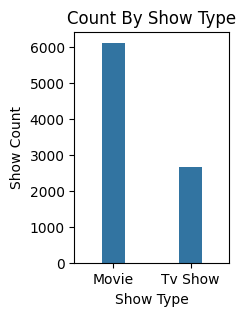

In [ ]:
#Graphical analysis
plt.figure(figsize=(2, 3))
sns.countplot(data=cleansed_data, x='type',width=0.3)
plt.title('Count By Show Type', fontsize= 12)
plt.xlabel('Show Type')
plt.ylabel('Show Count')
plt.show()

**Observation**: Movies make upto 70% of the overall library ads compared to TV Shows. Netflix started as a movie rental platform since inception and their platform remains heavily loaded with feature flims.

Category - Decade Analysis

In [ ]:
# Nongraphical analysis
cleansed_data['decade_label'].value_counts().sort_index(ascending= False)

,count
decade_label,
2020s,1545
2010s,5913
2000s,807
1990s,274
1980s,129
1970s,70
1960s,25
1950s,11
1940s,15


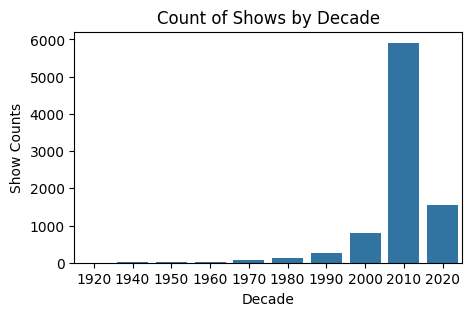

In [ ]:
#Graphical analysis
plt.figure(figsize=(5, 3))
sns.countplot(data=cleansed_data, x='decades', order=cleansed_data['decades'].value_counts().sort_index().index)
plt.xlabel('Decade')
plt.ylabel('Show Counts')
plt.title('Count of Shows by Decade',fontsize= 12)
plt.show()

**Observation**: There is a hockey stick growth curve in 2010. Volumn of content produced in 2010 alone is highest as ccompared to content released in past 90 years. During this timeline Netflix shifted from just being library for old content turned into massive production studio for new content.

Category - Rating Analysis

In [ ]:
# Nongraphical analysis
cleansed_data['rating'].value_counts()

,count
rating,
Tv-Ma,3205
Tv-14,2157
Tv-Pg,861
R,799
Pg-13,490
Tv-Y7,333
Tv-Y,306
Pg,287
Tv-G,220


In [ ]:
cleansed_data['target_audience'].value_counts()

,count
target_audience,
Adults,4007
Teens,3795
Kids,906
Unrated/Other,82


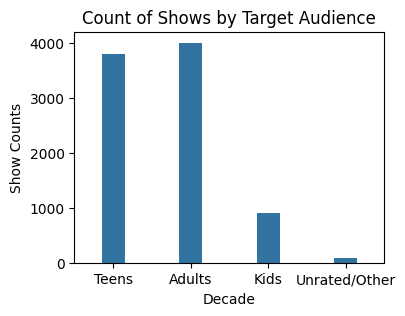

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=cleansed_data, x='target_audience',width=0.3)
plt.xlabel('Decade')
plt.ylabel('Show Counts')
plt.title('Count of Shows by Target Audience',fontsize= 12)
plt.show()

**Observation**: The 'Adult' & 'Teens' content dominates the platform as compared to 'Kids' content which is very low. Netflix has strategically positioned themselves as platform for Adult and Teen content streaming platform. While kids content is low their primary investment is towards Adult content to keep them subscribed.

Category - Seasonality Analysis by Month

In [ ]:
# Nongraphical analysis - Best mmonth when movies were relased were in July i.e 827 movies whilst lowest were relased during February i.e. 562
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
cleansed_data['month_added'] = pd.Categorical(cleansed_data['month_added'],categories= month_order)
counts = cleansed_data['month_added'].value_counts().sort_index()

range_val = counts.max()-counts.min()
percentacle_surge = (range_val/counts.min())*100

print(f"Difference between best month release to lowest month relase is : {range_val}")
print(f"Percentage Surge is : {percentacle_surge:.2f}% during peak season\n")
print(f"Monthwise count of movies released:\n {counts}")


Difference between best month release to lowest month relase is : 265
Percentage Surge is : 47.15% during peak season

Monthwise count of movies released:
 month_added
January      737
February     562
March        741
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     812
Name: count, dtype: int64


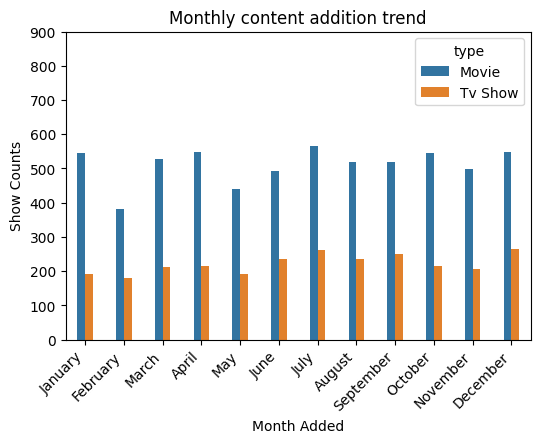

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=cleansed_data,x='month_added',width=0.4,hue='type') #Doughed counterplot
plt.xlabel('Month Added')
plt.ylabel('Show Counts')
plt.ylim(0, 900)
plt.title('Monthly content addition trend',fontsize= 12)
# Use plt.setp to set properties of the x-axis tick labels
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')
plt.show()

**Observation**: Both movies and TV shows hits a peak during July summer holidays and December Winter break. However, throughout movies consistently leads TV shows. So Netflix follows Dual season strategy, where they drop blockbuster shows during July holidays and binge worthly shows at the time of Xmas and New year. Also observe there is drop in February due to post holiday cooldown;

####Insights
*Netflix operates on a high volumn adult centric content. The platform's growth is massively concentatrated in last decade with clear strategy for release preferences during holiady windows to capture maximum viewrs attention.*

###Analysis2: Comparison of tv shows vs. movies

In [ ]:
#Find the number of movies produced in each country and pick the top 10 countries.
#movie_country_dataset = country_dataset.loc[country_dataset['type'] == 'Movie']
#movie_country_dataset.head(10)

movie_top10_country= (country_dataset[country_dataset['type'] == 'Movie']
                      .groupby('country')['title']
                      .nunique()
                      .sort_values(ascending=False)
                      .head(10))
movie_top10_country

,title
country,
United States,2749
India,962
United Kingdom,534
Unknown,439
Canada,319
France,303
Germany,182
Spain,171
Japan,119


In [ ]:
#Find the number of Tv Shows produced in each country and pick the top 10 countries.
tv_top10_country = (country_dataset[country_dataset['type'] == 'Tv Show']
                    .groupby('country')['title']
                    .nunique()
                    .sort_values(ascending=False)
                    .head(10))
tv_top10_country

,title
country,
United States,931
Unknown,390
United Kingdom,271
Japan,197
South Korea,170
Canada,126
France,90
India,84
Taiwan,70


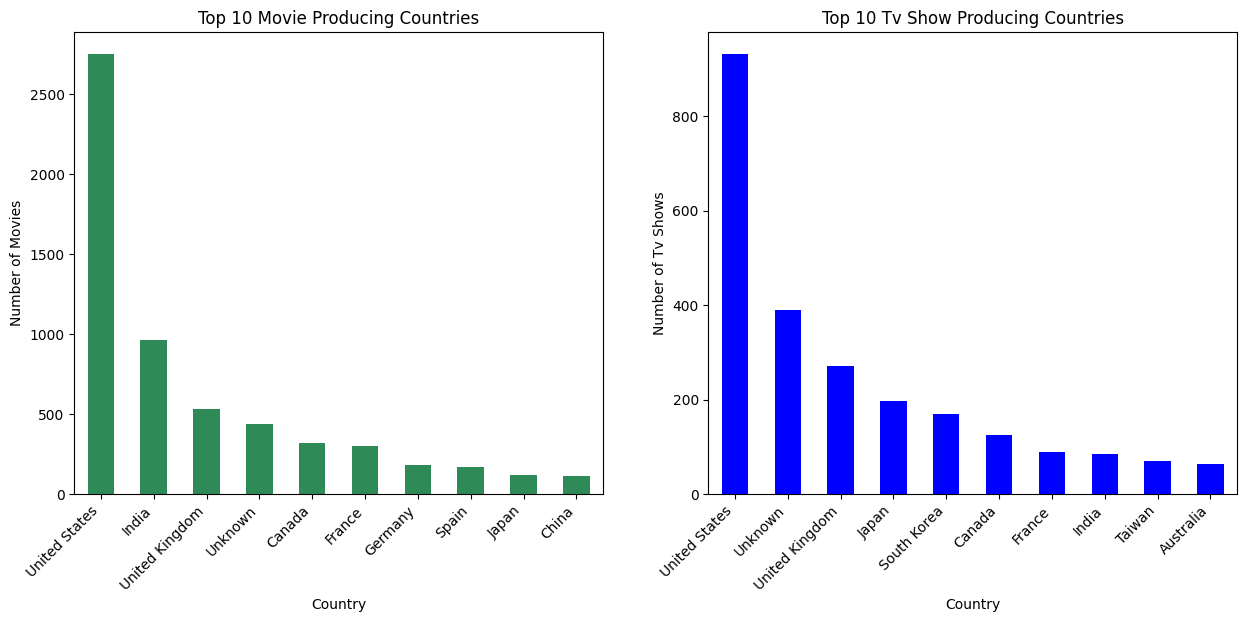

In [ ]:
plt.figure(figsize=(15, 6))

#------Left Plot-----------
plt.subplot(1,2,1)
movie_top10_country.plot(kind='bar', color='seagreen')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.title('Top 10 Movie Producing Countries',fontsize= 12)
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')

#------Right Plot-----------
plt.subplot(1,2,2)
tv_top10_country.plot(kind='bar', color='blue')
plt.xlabel('Country')
plt.ylabel('Number of Tv Shows')
plt.title('Top 10 Tv Show Producing Countries',fontsize= 12)
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')

plt.show()

**Observation**: USA dominates the market in both movie and Tv Series production while India holds a massive lead in movie production and fewer TV shows. India's library is dominated my Bollywoord and regional cinemas leaading is to an unerstanidng that Netfix's strategy in India is currently movie first.

**Data Quality Observation**: Unknown is 4th largest in movies and 2nd largest in Tv Shows. So large volumn of data is missing country informtion. This is area of improvement for Data Collection process.

In [ ]:
df_combined = pd.concat([movie_top10_country, tv_top10_country], axis=1)
df_combined.columns = ['Movies', 'Tv Shows']
df_combined = df_combined.fillna(0)
df_combined['Total'] = df_combined['Movies'] + df_combined['Tv Shows']
df_final = df_combined.sort_values(by='Total', ascending=False).head(10)
df_final

,Movies,Tv Shows,Total
country,,,
United States,2749.0,931.0,3680.0
India,962.0,84.0,1046.0
Unknown,439.0,390.0,829.0
United Kingdom,534.0,271.0,805.0
Canada,319.0,126.0,445.0
France,303.0,90.0,393.0
Japan,119.0,197.0,316.0
Germany,182.0,0.0,182.0
Spain,171.0,0.0,171.0


<Figure size 600x400 with 0 Axes>

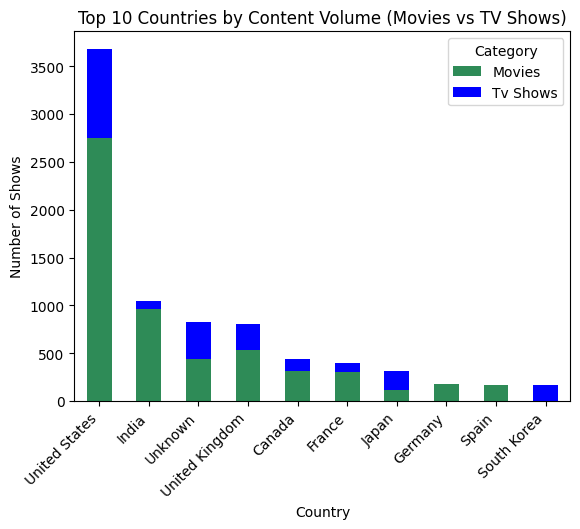

In [ ]:
plt.figure(figsize=(6, 4))
df_final[['Movies','Tv Shows']].plot(kind='bar', stacked=True, color=['seagreen', 'blue'])
plt.xlabel('Country')
plt.ylabel('Number of Shows')
plt.title('Top 10 Countries by Content Volume (Movies vs TV Shows)',fontsize= 12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.show()



**Observation:** We see that green bar i.e Movies is much taller than blue baars i.e Tv Shows. For all top nations movies are the major chunk of library and hence Netflix is more likely to offer movies in higher volumn than Tv shows are more selective collection.

####Insights

*Allmost top content producing nations are more inclined towards movie production. Netflix has higher investment on movies that keeps people paying for subscription than selective Tv shows*

###Analysis3: What is the best time to launch a TV show?

In [ ]:
#Find which is the best month to release the Tv-show or the movie. Do the
#analysis separately for Tv-shows and Movies

movie_best_month= (cleansed_data[cleansed_data['type'] == 'Movie']
                      .groupby('month_added')['show_id']
                      .count()
                      .reindex(month_order))

tv_best_month= (cleansed_data[cleansed_data['type'] == 'Tv Show']
                      .groupby('month_added')['show_id']
                      .count()
                      .reindex(month_order))

/tmp/ipykernel_6863/2856236968.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month_added')['show_id']
/tmp/ipykernel_6863/2856236968.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month_added')['show_id']


In [ ]:
#Find which is the best week to release the Tv-show or the movie. Do the analysis
#separately for Tv-shows and Movies
movie_best_week= (cleansed_data[cleansed_data['type'] == 'Movie']
                      .groupby('week_added')['show_id']
                      .count())

tv_best_week= (cleansed_data[cleansed_data['type'] == 'Tv Show']
                      .groupby('week_added')['show_id']
                      .count())

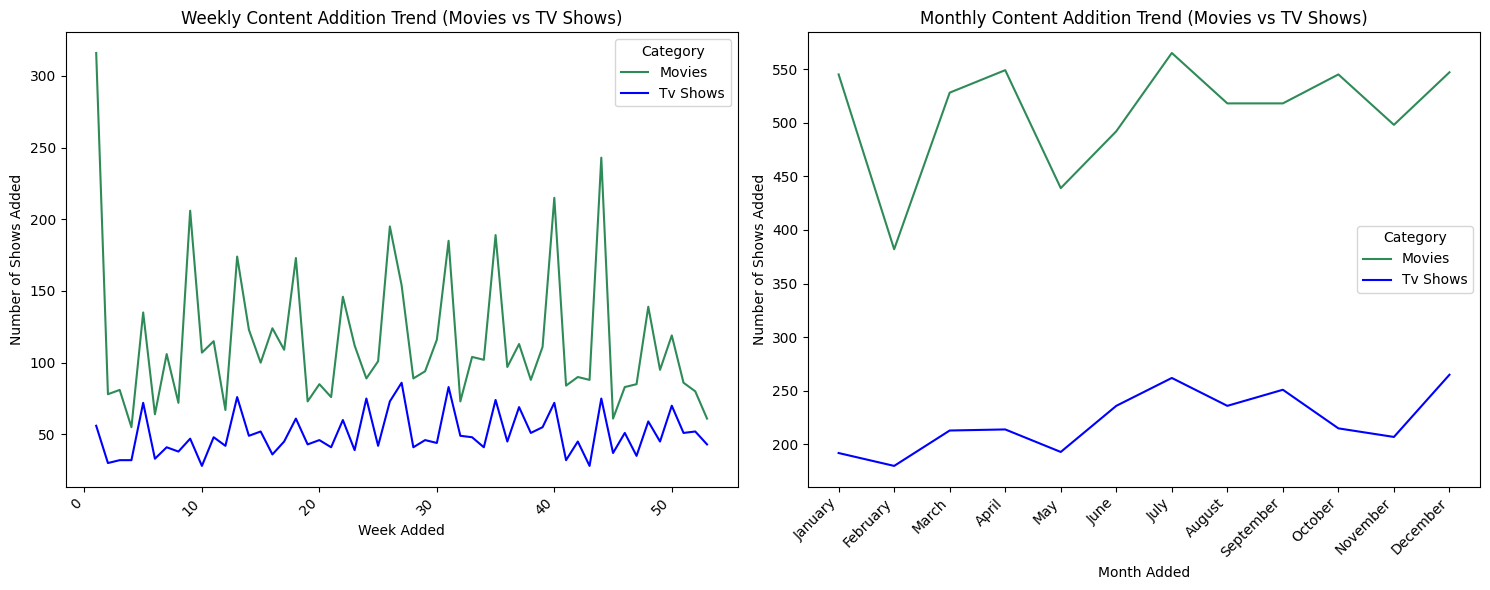

In [ ]:
plt.figure(figsize=(15, 6))

#------Left Plot-----------
plt.subplot(1,2,1)
sns.lineplot(data= movie_best_week.sort_index(), label = 'Movies', color = 'seagreen')
sns.lineplot(data=tv_best_week.sort_index(), label = 'Tv Shows', color = 'blue')
plt.xlabel('Week Added')
plt.ylabel('Number of Shows Added')
plt.title('Weekly Content Addition Trend (Movies vs TV Shows)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()

#------Right Plot-----------
plt.subplot(1,2,2)
sns.lineplot(data= movie_best_month, label = 'Movies', color = 'seagreen')
sns.lineplot(data=tv_best_month, label = 'Tv Shows', color = 'blue')
plt.xlabel('Month Added')
plt.ylabel('Number of Shows Added')
plt.title('Monthly Content Addition Trend (Movies vs TV Shows)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()

plt.show()

**Observation:** In both the charts Movie lines are consistently higher than the TV series denoted by blue lines. Except February with significant dip for both the categories of content, Movies peak in July with Tv shows shows a steady climb through summer into december. There are massive spike at regular intervals for Movies roughly every 4-5 weeks

####Insights

*Large volumn of licensed movies are uploaded on Netflix early for each month to maintain latest content for viewers. There is cool off period at the begining of year after a massive push during winter holidays. Netflix relies on Movies for volumn of content while Tv Shows for cinsistency .*


###Analysis4: Analysis of actors/directors of different types of shows/movies.

In [ ]:
#Identify the top 10 actor who have appeared in most movies or TV shows.
top10_actor_movies = cast_dataset[cast_dataset['type']=='Movie'].groupby('cast')['title'].nunique().nlargest(10)
top10_actor_tvshows = cast_dataset[cast_dataset['type']=='Tv Show'].groupby('cast')['title'].nunique().nlargest(10)

#Identify the top 10 directors who have appeared in most movies or TV shows.
top10_dir_movies = dircetor_dataset[dircetor_dataset['type']=='Movie'].groupby('director')['title'].nunique().nlargest(10)
top10_dir_tvshows = dircetor_dataset[dircetor_dataset['type']=='Tv Show'].groupby('director')['title'].nunique().nlargest(10)

print("Top 10 Actors in movies:\n", top10_actor_movies)
print("Top 10 Actors in Tv Shows:\n", top10_actor_tvshows)

print("Top 10 Director in movies:\n", top10_dir_movies)
print("Top 10 Director in Tv Shows:\n", top10_dir_tvshows)


Top 10 Actors in movies:
 cast
Unknown             475
Anupam Kher          42
Shah Rukh Khan       35
Naseeruddin Shah     32
Akshay Kumar         30
Om Puri              30
Amitabh Bachchan     28
Julie Tejwani        28
Paresh Rawal         28
Boman Irani          27
Name: title, dtype: int64
Top 10 Actors in Tv Shows:
 cast
Unknown               350
Takahiro Sakurai       25
Yuki Kaji              19
Daisuke Ono            17
Junichi Suwabe         17
Ai Kayano              16
Yuichi Nakamura        16
Jun Fukuyama           15
Yoshimasa Hosoya       15
David Attenborough     14
Name: title, dtype: int64
Top 10 Director in movies:
 director
Unknown                187
Rajiv Chilaka           22
Jan Suter               21
Raúl Campos             19
Suhas Kadav             16
Jay Karas               15
Marcus Raboy            15
Cathy Garcia-Molina     13
Jay Chapman             12
Martin Scorsese         12
Name: title, dtype: int64
Top 10 Director in Tv Shows:
 director
Unknown     

/tmp/ipykernel_6863/1693036501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_actor_movies.values, y=top10_actor_movies.index, palette='magma')


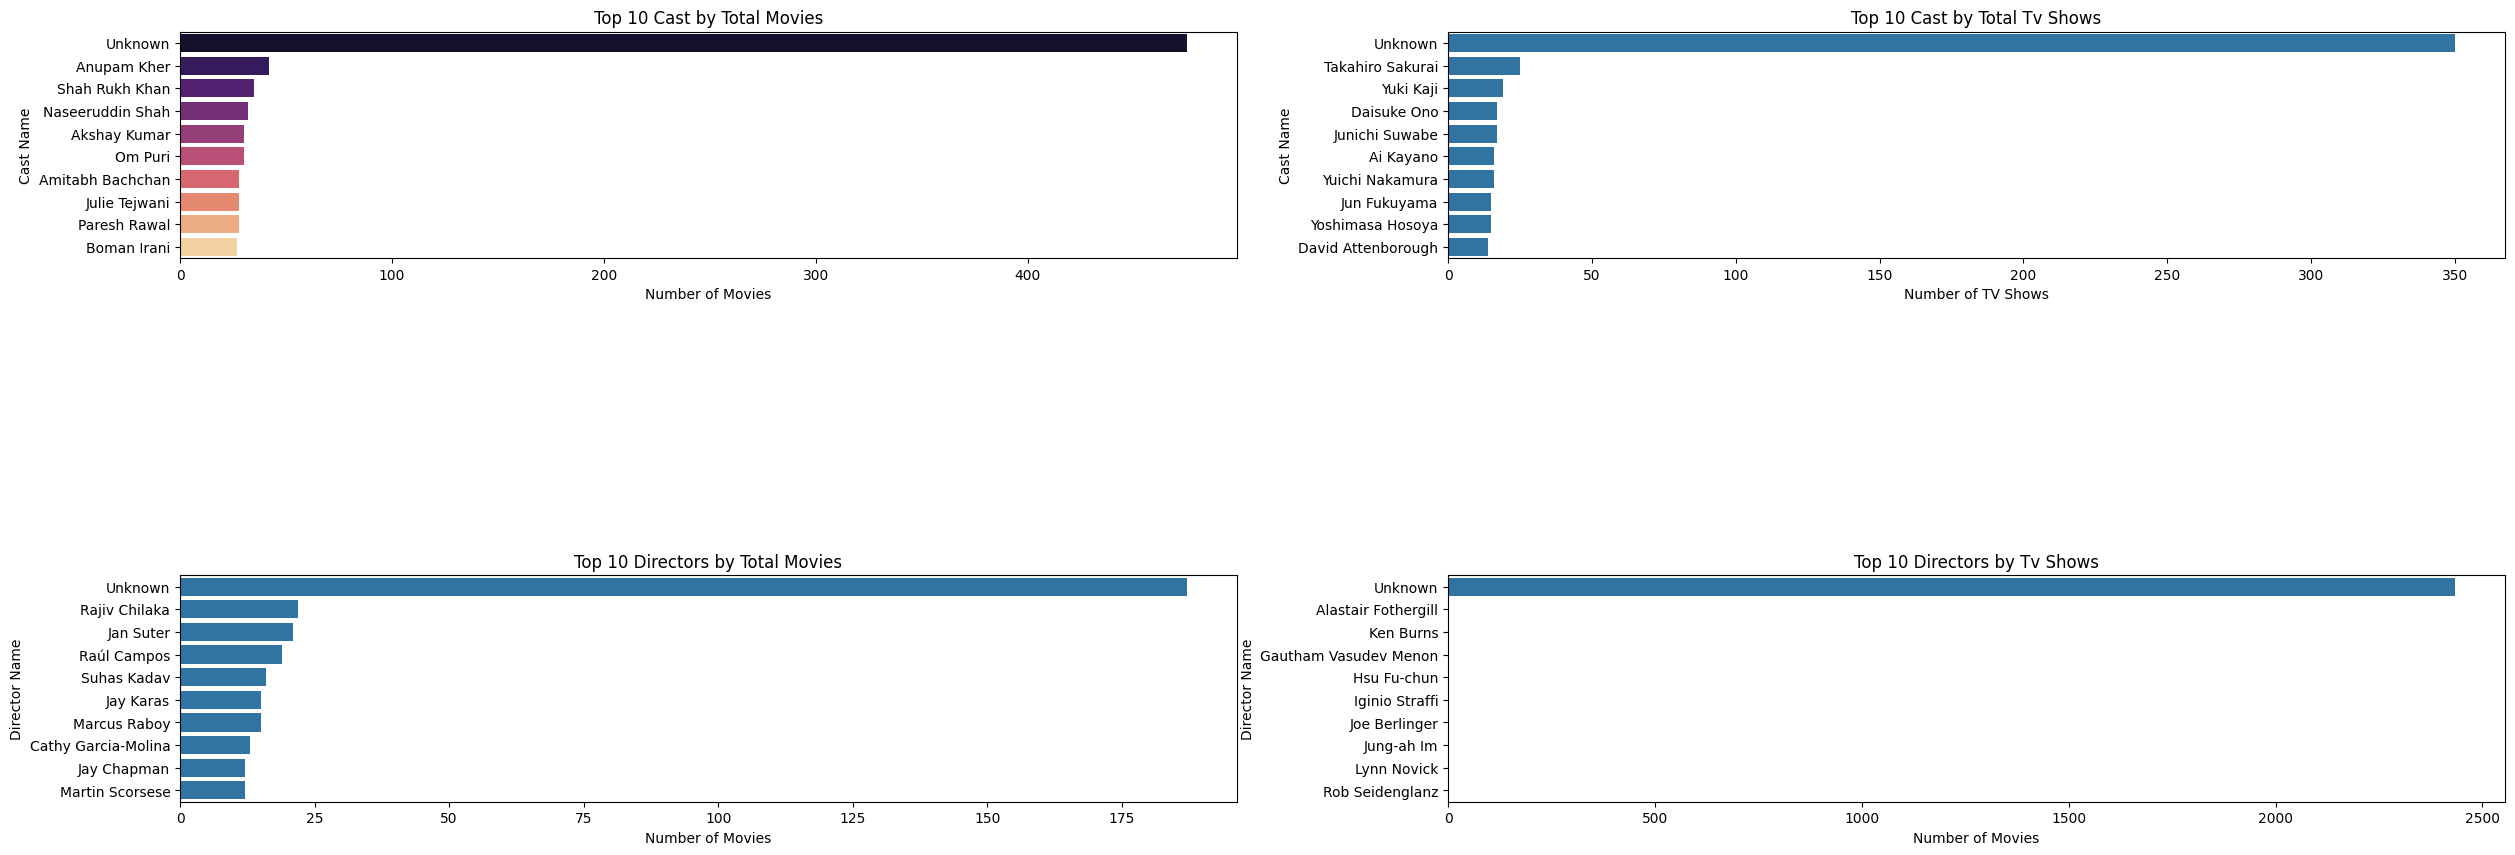

In [ ]:
plt.figure(figsize=(30, 10))

#------Left Plot-----------
plt.subplot(3,2,1)
sns.barplot(x=top10_actor_movies.values, y=top10_actor_movies.index, palette='magma')
plt.xlabel('Number of Movies')
plt.ylabel('Cast Name')
plt.title('Top 10 Cast by Total Movies')

#------Right Plot-----------
plt.subplot(3,2,2)
sns.barplot(x=top10_actor_tvshows.values, y=top10_actor_tvshows.index)
plt.xlabel('Number of TV Shows')
plt.ylabel('Cast Name')
plt.title('Top 10 Cast by Total Tv Shows')

#------Bottom Left Plot-----------

plt.subplot(3,2,5)
sns.barplot(x=top10_dir_movies.values, y=top10_dir_movies.index)
plt.xlabel('Number of Movies')
plt.ylabel('Director Name')
plt.title('Top 10 Directors by Total Movies')

#------Bottom Right Plot-----------

plt.subplot(3,2,6)
sns.barplot(x=top10_dir_tvshows.values, y=top10_dir_tvshows.index)
plt.xlabel('Number of Movies')
plt.ylabel('Director Name')
plt.title('Top 10 Directors by Tv Shows')

plt.show()

**Observation**:The list is dominated by actors from India like Anupam Kher or Shah Rukh Khan toping the list.Top directors have 20 o 30 shows on the platform

####Insights

*Significant amount of cast & director is missing in the data set and is one of the imporvement step for data collection. Netflix platform is dominated by superstar movies which has major fanbase across globe to maintain retention and engagement.*

###Analysis5: Which genre movies are more popular or produced more

In [ ]:
#Set up word cloud for genre
genre_text = " ".join(cat for cat in listed_dataset.listed_in) #Set up genre as a large string for wordcloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='magma',
                      collocations=False).generate(genre_text)

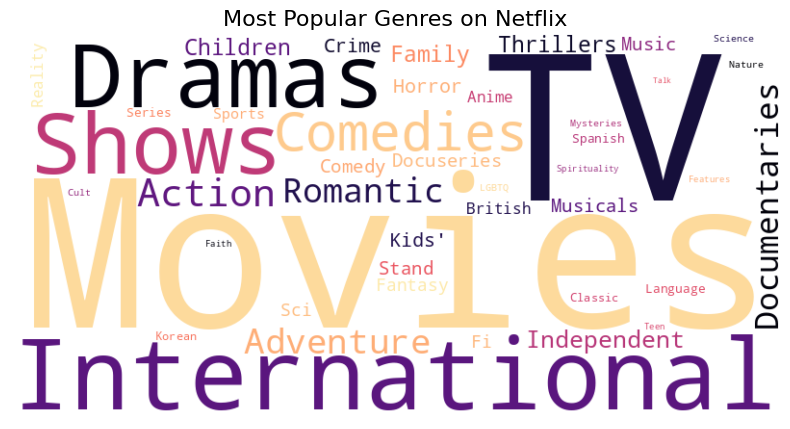

In [ ]:
#Display the cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Popular Genres on Netflix', fontsize=16)
plt.show()

**Observation**: Words like International, Dramas, Movies and comedies appear in large fonts

####Insights

*International keyword highlights that Netflix primary growth startegy is global diversification. They are moving aways from US only platform to worlds largest library of non-english and cross geo content*

###Analysis6: Find After how many days the movie will be added to Netflix after the release of the movie (you can consider the recent past data)

In [ ]:
recent_movies = cleansed_data[cleansed_data['year_added'] >= 2010].copy()
recent_movies['Gap_years'] = recent_movies['year_added'] - recent_movies['release_year']

#Find the Mode (The most common wait time)
best_time_to_add = recent_movies['Gap_years'].mode()[0]
print(f"In recent years the most common time gap for a movie to be added is: {best_time_to_add} years.")

old_movies = cleansed_data[cleansed_data['year_added'] <= 2010].copy()
old_movies['Gap_years'] = old_movies['year_added'] - old_movies['release_year']

#Find the Mode (The most common wait time)
earler_time_to_add = old_movies['Gap_years'].mode()[0]
print(f"Earlier, common time gap for a movie to be added was: {earler_time_to_add} years.")

In recent years the most common time gap for a movie to be added is: 0 years.
Earlier, common time gap for a movie to be added was: 2 years.


**Onservation**: Netflix is first window partner. They are adding movies in the same year it is released in recent times. In early age Netflix would wait for price slash for movie liscences before they would be uploaded on platform.

####Insights

*Netflix primary stratey is immediate integration during the same calendar year. Their vision is to be producer of originals rather than only distributor of old movies*



---



##Executive Summary - Netflix Content Strategy

1. **Netflix Core Library Structure**
Our analysis confirms that Netflix remains a movie-heavy platform, with feature films are greater in number than TV shows by 70% of total set. Production of TV shows is more consistent and stable which suggest strategic approach towards long term subscriber retention while Movies are primary strategy for volumn of content and variaty for continuity of engagement.

2. **Global Production Leaders**
The United States and India are the primary leaders in licenced content where USA outperforms in both the segments of content. India is powerhouse of bollywood movies and versatile regional cinemas.South Korea & Japan are emerging markets for Tv Shows and it highlights that Netflix's long terms vision is global expansion towards more specialized international gerne like k-darmas.

3. **Seasonality**
Netflix follows Holiday Pulse stratgy by timing its movie uploads during July i.e summer holidays and December i.e Thanks Giving and New Years. It targets to achive more engagement during the holiday season due to peak leisure time with Adults and Students.
Early month upload cycle reflects Netflix aligns their effort towards freshness of the content aligned with every billing cycle

4. **The "Originals" Era**
The data shows that there was explosion of content on Netflix platform in 2010 which indicates pivotal shift from content distribution business strategy towards global production. Hitorically, Netflix had a gap mode of 2 days which shifted 2010 onwards to 0 days indicating Netflix shifted to same year content integration strategy as release year. So they are now first window destination for new entertainment.

5. **Audience Targeting**
Netflix library is heavily loaded with Adult(TV-MA) and Teens (TV-14), while Kids content is vital niche it is significally lower in concentation on the platform. So this indicates Netflix's primary business goal is to capture binge watching adult demographics

6. **Data Quality Reflection**
There were several data quality gaps observed through the analysis with unknown or missing values for Directors/Country and samll percentage of illlogical entires. We were able to filter out these anomolies  and identify startegic patterns driving the platform.

##Key Recomendations

1. Double down on the global engagment for originals and regional content for all demographics
2. Maintain a consistent content provisioning cycle during the low peak seasons like Feb for consistent engagment
3. Netflix data is heavily skewed towards Adult and Teen content. While adult content is saturated,Netflix should invest around kids and family niche to maintain viewer retention with high quality kids content as it is a daliy need for majority of household.
4. Netflix should invest in Metadata governance as major data quality issues were found and streamline for more comprehensive data engagement to suport AI expansion in future as well.


